# Raw **R**egularized **A**djusted **G**oals

## 1. ¿Qué observa Raw RAG?

Raw RAG observa quién estaba jugando cuando se creó o se evitó peligro, ajusta por compañeros, rivales y recencia, y estima el impacto individual ofensivo y defensivo de cada jugador.

In [1]:
from pathlib import Path
import json
import warnings

import matplotlib.pyplot as plt
from matplotlib.patches import Circle, Rectangle
import numpy as np
import pandas as pd
from scipy import sparse
from sklearn.linear_model import Ridge, RidgeCV
from IPython.display import Markdown, display

warnings.filterwarnings("ignore", category=UserWarning)
SEED = 42
rng = np.random.default_rng(SEED)

BLUE = "#2563EB"
BLUE_LIGHT = "#BFDBFE"
GOLD = "#D89B19"
GOLD_LIGHT = "#FDE7A9"
INK = "#1F2937"
MUTED = "#6B7280"
GRID = "#E5E7EB"
PAPER = "#FCFCFA"

plt.rcParams.update({
    "figure.facecolor": PAPER,
    "axes.facecolor": PAPER,
    "axes.edgecolor": GRID,
    "axes.labelcolor": INK,
    "text.color": INK,
    "xtick.color": MUTED,
    "ytick.color": MUTED,
    "font.size": 12,
    "axes.titleweight": "bold",
})

def finish_chart(fig, subtitle, subtitle_y=0.925):
    fig.text(0.06, subtitle_y, subtitle, fontsize=10.5, color=MUTED, ha="left")
    fig.text(0.975, 0.965, "✦", fontsize=17, color=GOLD, ha="right", va="top")

def clean_axes(ax, keep_left=True, keep_bottom=True):
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["left"].set_visible(keep_left)
    ax.spines["bottom"].set_visible(keep_bottom)
    ax.grid(axis="x", color=GRID, linewidth=0.8, alpha=0.8)
    ax.set_axisbelow(True)

def fit_raw_rag(frame, reference_date=None):
    """Misma especificación que scripts/core.py::_train_raw_rag."""
    model_data = frame.copy()
    model_data["date"] = pd.to_datetime(model_data["date"])
    for column in ["teamA_players", "teamB_players"]:
        model_data[column] = model_data[column].apply(
            lambda value: value if isinstance(value, list) else json.loads(value)
        )
    reference_date = pd.Timestamp(reference_date or model_data["date"].max())
    model_data["days_ago"] = (reference_date - model_data["date"]).dt.days
    model_data["time_weight"] = np.exp(-np.log(2) * model_data["days_ago"] / 180)
    model_data["time_weight"] *= len(model_data) / model_data["time_weight"].sum()

    players = sorted(set().union(*model_data["teamA_players"], *model_data["teamB_players"]))
    player_index = {player: index for index, player in enumerate(players)}
    n_players = len(players)
    rows, cols, values, target, sample_weights = [], [], [], [], []

    for row_number, (_, segment) in enumerate(model_data.iterrows()):
        minutes = int(segment["minutes_played"])
        time_weight = float(segment["time_weight"])
        for perspective, (attackers, defenders, xg) in enumerate([
            (segment["teamA_players"], segment["teamB_players"], segment["teamA_xg"]),
            (segment["teamB_players"], segment["teamA_players"], segment["teamB_xg"]),
        ]):
            design_row = row_number * 2 + perspective
            for player in attackers:
                rows.append(design_row); cols.append(player_index[player]); values.append(1)
            for player in defenders:
                rows.append(design_row); cols.append(n_players + player_index[player]); values.append(-1)
            target.append(float(xg) / minutes)
            sample_weights.append(np.sqrt(minutes * time_weight))

    matrix = sparse.csr_matrix(
        (values, (rows, cols)), shape=(len(model_data) * 2, n_players * 2)
    )
    target = np.asarray(target)
    sample_weights = np.asarray(sample_weights)
    target_mean = np.average(target, weights=sample_weights)
    centered_target = target - target_mean
    alphas = np.logspace(-3, 3, 13)
    selector = RidgeCV(alphas=alphas, fit_intercept=True, cv=5)
    selector.fit(matrix, centered_target, sample_weight=sample_weights)
    model = Ridge(alpha=selector.alpha_, fit_intercept=True)
    model.fit(matrix, centered_target, sample_weight=sample_weights)

    ratings = pd.DataFrame({
        "player": players,
        "off_90": model.coef_[:n_players] * 90,
        "def_90": model.coef_[n_players:] * 90,
    })
    ratings["total_90"] = ratings["off_90"] + ratings["def_90"]
    return {
        "baseline_90": float((model.intercept_ + target_mean) * 90),
        "alpha": float(selector.alpha_),
        "ratings": ratings,
        "model": model,
        "players": players,
        "prepared": model_data,
    }

def draw_waterfall(ax, baseline, deltas, final_value, title):
    labels = ["Promedio"] + [label for label, _ in deltas] + ["Resultado"]
    cumulative = [baseline]
    for _, delta in deltas:
        cumulative.append(cumulative[-1] + delta)
    positions = np.arange(len(labels))
    ax.bar(0, baseline, color="#D1D5DB", edgecolor=INK, linewidth=0.8)
    for index, (_, delta) in enumerate(deltas, start=1):
        start = cumulative[index - 1]
        color = BLUE if delta >= 0 else GOLD
        ax.bar(index, delta, bottom=start, color=color, edgecolor=INK, linewidth=0.8)
        ax.plot([index - 0.55, index + 0.55], [start, start], color=MUTED, linewidth=0.8)
        ax.text(index, start + delta / 2, f"{delta:+.2f}", ha="center", va="center", color="white", fontweight="bold")
    ax.bar(len(labels) - 1, final_value, color="#9CA3AF", edgecolor=INK, linewidth=0.8)
    ax.text(0, baseline + 0.03, f"{baseline:.2f}", ha="center", fontweight="bold")
    ax.text(len(labels) - 1, final_value + 0.03, f"{final_value:.2f}", ha="center", fontweight="bold")
    ax.set_xticks(positions, labels)
    ax.set_ylabel("xG esperado por 90 minutos")
    ax.set_title(title, loc="left", pad=28)
    clean_axes(ax)

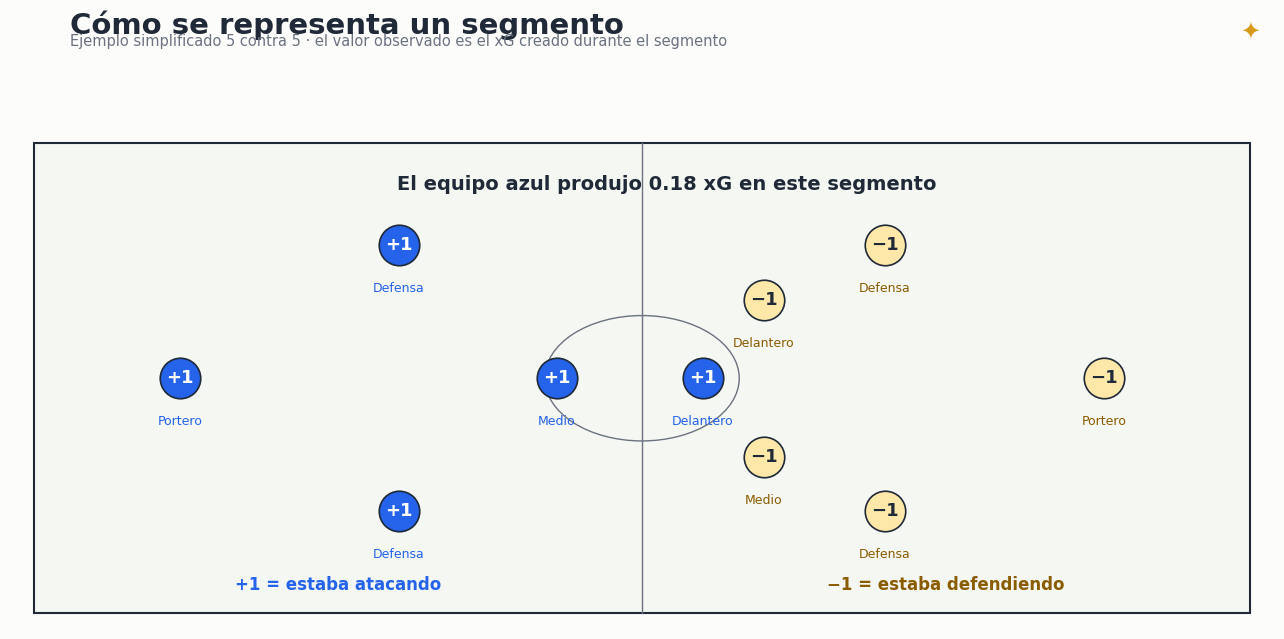

In [2]:
# Contrato visual: explicar la codificación de un segmento; diagrama estático; dos raíces de color y etiquetas directas.
fig, ax = plt.subplots(figsize=(13, 6.5))
ax.add_patch(Rectangle((0, 0), 100, 60, facecolor="#F4F7F2", edgecolor=INK, linewidth=1.5))
ax.plot([50, 50], [0, 60], color=MUTED, linewidth=1)
ax.add_patch(Circle((50, 30), 8, fill=False, edgecolor=MUTED, linewidth=1))

attack = [(12, 30, "Portero"), (30, 13, "Defensa"), (30, 47, "Defensa"), (43, 30, "Medio"), (55, 30, "Delantero")]
defense = [(88, 30, "Portero"), (70, 13, "Defensa"), (70, 47, "Defensa"), (60, 20, "Medio"), (60, 40, "Delantero")]
for x, y, label in attack:
    ax.scatter(x, y, s=850, color=BLUE, edgecolor=INK, linewidth=1.2, zorder=3)
    ax.text(x, y, "+1", color="white", ha="center", va="center", fontweight="bold", fontsize=13)
    ax.text(x, y - 6, label, ha="center", color=BLUE, fontsize=9)
for x, y, label in defense:
    ax.scatter(x, y, s=850, color=GOLD_LIGHT, edgecolor=INK, linewidth=1.2, zorder=3)
    ax.text(x, y, "−1", color=INK, ha="center", va="center", fontweight="bold", fontsize=13)
    ax.text(x, y - 6, label, ha="center", color="#8A5C00", fontsize=9)

ax.annotate("El equipo azul produjo 0.18 xG en este segmento", xy=(52, 54), xytext=(52, 54),
            ha="center", fontsize=14, fontweight="bold")
ax.text(25, 3, "+1 = estaba atacando", ha="center", color=BLUE, fontweight="bold")
ax.text(75, 3, "−1 = estaba defendiendo", ha="center", color="#8A5C00", fontweight="bold")
ax.set_xlim(-2, 102); ax.set_ylim(-2, 62); ax.axis("off")
fig.suptitle("Cómo se representa un segmento", x=0.06, ha="left", fontsize=21, fontweight="bold")
finish_chart(fig, "Ejemplo simplificado 5 contra 5 · el valor observado es el xG creado durante el segmento")
plt.tight_layout(rect=(0, 0, 1, 0.90))
plt.show()

### El coeficiente es lo que el jugador añade

El modelo empieza desde un nivel promedio. Después suma el ataque de los jugadores propios y resta la calidad defensiva del rival. El coeficiente resume cuánto cambia la expectativa cuando ese jugador está presente.

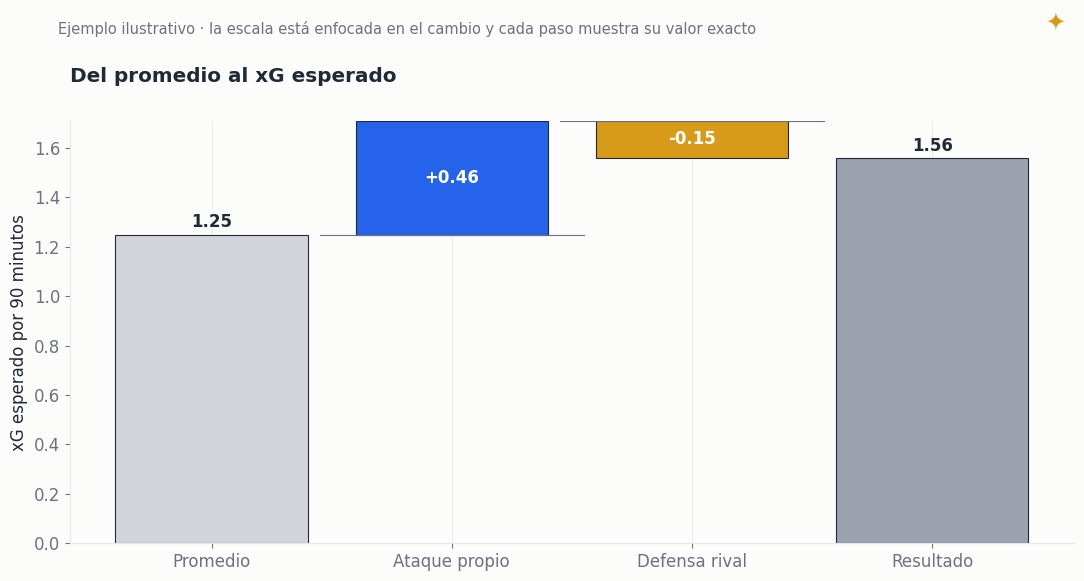

In [3]:
# Contrato visual: mostrar una suma aditiva; waterfall; escala enfocada y valores directos.
baseline_demo = 1.25
deltas_demo = [("Ataque propio", 0.46), ("Defensa rival", -0.15)]
final_demo = baseline_demo + sum(value for _, value in deltas_demo)
fig, ax = plt.subplots(figsize=(11, 6))
draw_waterfall(ax, baseline_demo, deltas_demo, final_demo, "Del promedio al xG esperado")
finish_chart(fig, "Ejemplo ilustrativo · la escala está enfocada en el cambio y cada paso muestra su valor exacto")
plt.tight_layout(rect=(0, 0, 1, 0.90))
plt.show()

## 2. La forma reciente pesa más

Raw RAG no trata igual un partido de ayer y uno de hace un año. Usa una **half-life de 180 días**: después de seis meses, un segmento conserva la mitad del peso; después de un año, una cuarta parte.

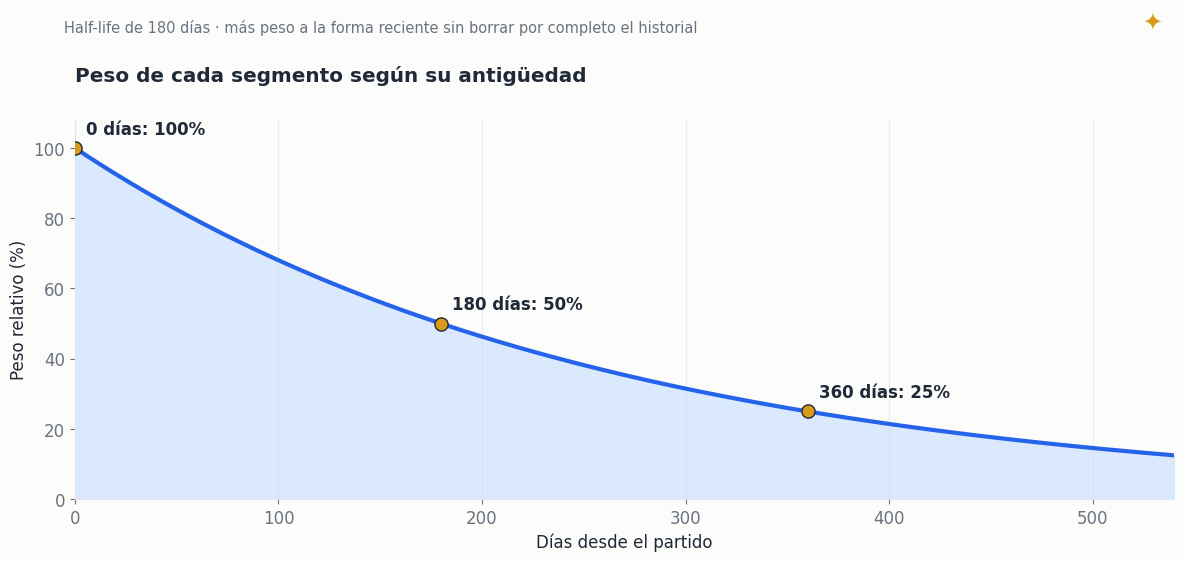

In [4]:
# Contrato visual: explicar el peso temporal; línea con 181 puntos; una raíz azul y tres anotaciones.
days = np.arange(0, 541, 3)
weights = np.exp(-np.log(2) * days / 180)
fig, ax = plt.subplots(figsize=(12, 5.8))
ax.plot(days, weights * 100, color=BLUE, linewidth=3)
ax.fill_between(days, weights * 100, color=BLUE_LIGHT, alpha=0.55)
for day, weight in [(0, 100), (180, 50), (360, 25)]:
    ax.scatter(day, weight, s=90, color=GOLD, edgecolor=INK, zorder=3)
    ax.annotate(f"{day} días: {weight}%", (day, weight), xytext=(8, 10), textcoords="offset points", fontweight="bold")
ax.set(xlabel="Días desde el partido", ylabel="Peso relativo (%)", xlim=(0, 540), ylim=(0, 108))
ax.set_title("Peso de cada segmento según su antigüedad", loc="left", pad=28)
clean_axes(ax)
finish_chart(fig, "Half-life de 180 días · más peso a la forma reciente sin borrar por completo el historial")
plt.tight_layout(rect=(0, 0, 1, 0.90))
plt.show()

## 3. No basta con estar al lado del mejor

Un `+/-` ingenuo puede premiar a quien siempre comparte cancha con una estrella. Raw RAG compara muchas combinaciones y usa **Ridge** para repartir el crédito de forma más estable.

Aquí creamos datos pequeños al azar. La *Estrella* tiene impacto real; el *Acompañante* juega frecuentemente con ella, pero también aparece en minutos sin ella. Esa rotación permite separar sus efectos.

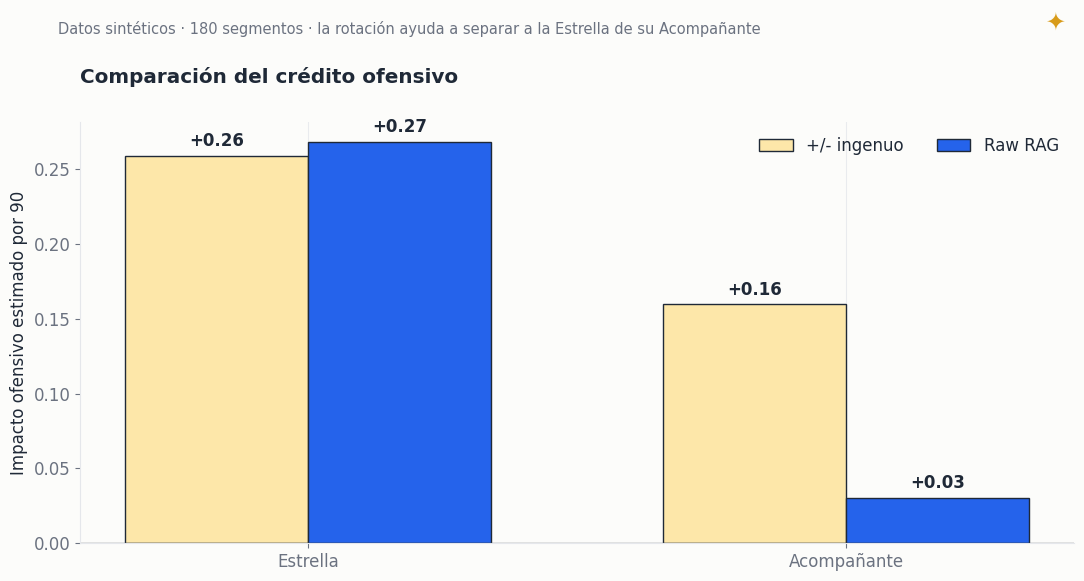

In [5]:
synthetic_players = ["Estrella", "Acompañante", "Rotación A", "Rotación B", "Rival fuerte", "Rival medio", "Rival débil", "Rival rotación"]
true_off_90 = {player: 0.0 for player in synthetic_players}
true_def_90 = {player: 0.0 for player in synthetic_players}
true_off_90.update({"Estrella": 0.42, "Rival fuerte": 0.24, "Rival débil": -0.12})
true_def_90.update({"Rotación A": 0.12, "Rival medio": 0.09, "Rival débil": -0.08})

synthetic_rows = []
base_rate = 1.25 / 90
start_date = pd.Timestamp("2025-01-01")
for segment_id in range(180):
    star_plays = rng.random() < 0.72
    if star_plays:
        team_a = ["Estrella", "Acompañante", rng.choice(["Rotación A", "Rotación B"])]
    else:
        team_a = ["Acompañante", "Rotación A", "Rotación B"]
    team_b = list(rng.choice(["Rival fuerte", "Rival medio", "Rival débil", "Rival rotación"], size=3, replace=False))
    minutes = int(rng.integers(6, 16))
    rate_a = base_rate + sum(true_off_90[p] for p in team_a) / 90 - sum(true_def_90[p] for p in team_b) / 90
    rate_b = base_rate + sum(true_off_90[p] for p in team_b) / 90 - sum(true_def_90[p] for p in team_a) / 90
    synthetic_rows.append({
        "segment_id": segment_id,
        "match_id": segment_id // 6,
        "date": start_date + pd.Timedelta(days=segment_id),
        "teamA_players": team_a,
        "teamB_players": team_b,
        "teamA_xg": max(0, rate_a * minutes + rng.normal(0, 0.025)),
        "teamB_xg": max(0, rate_b * minutes + rng.normal(0, 0.025)),
        "minutes_played": minutes,
    })
synthetic = pd.DataFrame(synthetic_rows)
synthetic_fit = fit_raw_rag(synthetic)

naive_rows = []
league_rate = (
    synthetic["teamA_xg"].sum() + synthetic["teamB_xg"].sum()
) / (2 * synthetic["minutes_played"].sum())
for player in synthetic_players:
    observed_xg = observed_minutes = 0.0
    for _, row in synthetic.iterrows():
        if player in row["teamA_players"]:
            observed_xg += row["teamA_xg"]; observed_minutes += row["minutes_played"]
        if player in row["teamB_players"]:
            observed_xg += row["teamB_xg"]; observed_minutes += row["minutes_played"]
    naive_rows.append({"player": player, "+/- ingenuo": (observed_xg / observed_minutes - league_rate) * 90})

synthetic_comparison = pd.DataFrame(naive_rows).merge(
    synthetic_fit["ratings"][["player", "off_90"]].rename(columns={"off_90": "Raw RAG"}), on="player"
)
focus = synthetic_comparison[synthetic_comparison["player"].isin(["Estrella", "Acompañante"])].set_index("player")

# Contrato visual: comparar atribución ingenua y ajustada; barras agrupadas; dos raíces y etiquetas directas.
fig, ax = plt.subplots(figsize=(11, 6))
x = np.arange(len(focus))
width = 0.34
bars_a = ax.bar(x - width/2, focus["+/- ingenuo"], width, label="+/- ingenuo", color=GOLD_LIGHT, edgecolor=INK)
bars_b = ax.bar(x + width/2, focus["Raw RAG"], width, label="Raw RAG", color=BLUE, edgecolor=INK)
ax.axhline(0, color=INK, linewidth=0.9)
ax.set_xticks(x, focus.index)
ax.set_ylabel("Impacto ofensivo estimado por 90")
ax.set_title("Comparación del crédito ofensivo", loc="left", pad=28)
ax.legend(frameon=False, ncol=2, loc="upper right")
for bars in [bars_a, bars_b]:
    ax.bar_label(bars, fmt="%+.2f", padding=4, fontweight="bold")
clean_axes(ax)
finish_chart(fig, "Datos sintéticos · 180 segmentos · la rotación ayuda a separar a la Estrella de su Acompañante")
plt.tight_layout(rect=(0, 0, 1, 0.90))
plt.show()

> **Límite importante:** el modelo aprende de las rotaciones. Si dos jugadores siempre aparecen juntos, ningún modelo puede saber con total certeza cuál de los dos produjo la diferencia.

## 4. Ahora sí: datos reales de La Liga

El archivo siguiente fue exportado de `vsp.sql`, pero el notebook ya no depende de esa base. Cada fila es un segmento real con fecha, alineaciones, minutos y xG de ambos equipos.

In [6]:
data_candidates = [Path("../data/raw_rag_la_liga.csv"), Path("data/raw_rag_la_liga.csv")]
DATA_PATH = next((path for path in data_candidates if path.exists()), None)
if DATA_PATH is None:
    raise FileNotFoundError("No se encontró data/raw_rag_la_liga.csv")

raw = pd.read_csv(DATA_PATH, encoding="utf-8-sig")
required_columns = {
    "segment_id", "match_id", "date", "home_team", "away_team",
    "teamA_players", "teamB_players", "teamA_xg", "teamB_xg", "minutes_played"
}
assert required_columns.issubset(raw.columns)
assert raw["segment_id"].is_unique
assert raw[["teamA_xg", "teamB_xg", "minutes_played"]].notna().all().all()
assert (raw["minutes_played"] > 0).all()
raw["date"] = pd.to_datetime(raw["date"])
for column in ["teamA_players", "teamB_players"]:
    raw[column] = raw[column].apply(json.loads)
    assert raw[column].map(len).gt(0).all()

coverage = pd.Series({
    "Segmentos": len(raw),
    "Partidos": raw["match_id"].nunique(),
    "Jugadores": len(set().union(*raw["teamA_players"], *raw["teamB_players"])),
    "Fecha inicial": raw["date"].min().date().isoformat(),
    "Fecha final": raw["date"].max().date().isoformat(),
})
display(coverage.to_frame("Cobertura"))

,Cobertura
Segmentos,14240
Partidos,997
Jugadores,1104
Fecha inicial,2022-12-29
Fecha final,2025-05-25


### Entrenamiento igual al backtesting

La especificación coincide con `scripts/core.py::_train_raw_rag`: xG por minuto, ataque y defensa separados, half-life de 180 días, peso por duración del segmento y `RidgeCV` con 13 niveles de regularización.

In [7]:
real_fit = fit_raw_rag(raw, reference_date=raw["date"].max())
ratings = real_fit["ratings"].copy()

minutes_by_player = {}
team_minutes = {}
for _, segment in real_fit["prepared"].iterrows():
    for player, team in [(p, segment["home_team"]) for p in segment["teamA_players"]] + [(p, segment["away_team"]) for p in segment["teamB_players"]]:
        minutes_by_player[player] = minutes_by_player.get(player, 0) + int(segment["minutes_played"])
        team_minutes[(player, team)] = team_minutes.get((player, team), 0) + int(segment["minutes_played"])

ratings["minutes"] = ratings["player"].map(minutes_by_player).fillna(0).astype(int)
ratings["team"] = ratings["player"].map(
    lambda player: max(
        ((team, mins) for (p, team), mins in team_minutes.items() if p == player),
        key=lambda item: item[1],
    )[0]
)
eligible = ratings[ratings["minutes"] >= 3150].copy()

print(f"Baseline de La Liga: {real_fit['baseline_90']:.2f} xG por 90")
print(f"Alpha elegido por RidgeCV: {real_fit['alpha']:g}")
print(f"Jugadores con al menos 3,150 minutos acumulados en la muestra: {len(eligible):,}")

Baseline de La Liga: 1.49 xG por 90
Alpha elegido por RidgeCV: 1000
Jugadores con al menos 3,150 minutos acumulados en la muestra: 227


## 5. ¿Quiénes aparecen arriba?

Para no convertir pocos minutos en una gran conclusión, los tres rankings visibles requieren al menos **3,150 minutos acumulados en todo el período de la muestra**, no por temporada. Un valor defensivo positivo significa que el jugador reduce el xG esperado del rival.

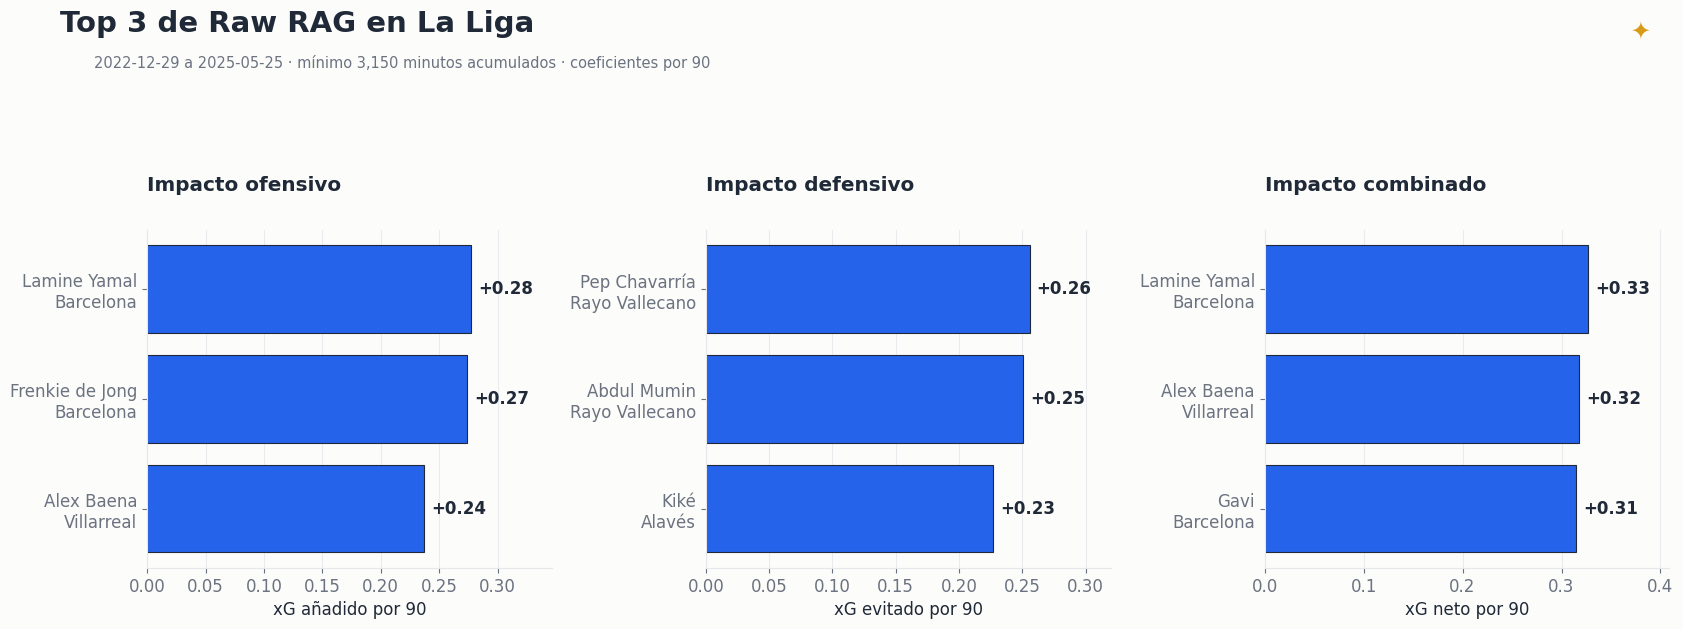

In [8]:
# Contrato visual: rankings top 3; barras horizontales; 3 categorías por panel; una raíz azul y etiquetas directas.
rank_specs = [
    ("off_90", "Impacto ofensivo", "xG añadido por 90"),
    ("def_90", "Impacto defensivo", "xG evitado por 90"),
    ("total_90", "Impacto combinado", "xG neto por 90"),
]
fig, axes = plt.subplots(1, 3, figsize=(17, 6.4))
top_tables = {}
for ax, (metric, title, xlabel) in zip(axes, rank_specs):
    top = eligible.nlargest(3, metric).sort_values(metric)
    top_tables[metric] = top.sort_values(metric, ascending=False)
    labels = [f"{player.split('_')[0]}\n{team}" for player, team in zip(top["player"], top["team"])]
    bars = ax.barh(labels, top[metric], color=BLUE, edgecolor=INK, linewidth=0.8)
    ax.bar_label(bars, fmt="%+.2f", padding=5, fontweight="bold")
    ax.set_title(title, loc="left", pad=28)
    ax.set_xlabel(xlabel)
    ax.set_xlim(left=min(0, top[metric].min() * 1.15), right=top[metric].max() * 1.25)
    clean_axes(ax)
fig.suptitle("Top 3 de Raw RAG en La Liga", x=0.04, ha="left", fontsize=21, fontweight="bold")
finish_chart(fig, f"{raw['date'].min().date()} a {raw['date'].max().date()} · mínimo 3,150 minutos acumulados · coeficientes por 90", subtitle_y=0.89)
plt.tight_layout(rect=(0, 0, 1, 0.82))
plt.show()

## 6. El Clásico, jugador por jugador

Usamos Barcelona–Real Madrid del **11 de mayo de 2025**. La fuente contiene **19 segmentos y 98 minutos**; el xG observado terminó **4.27–2.74**.

Para explicar la alineación inicial, la predicción se separa en tres piezas: promedio de La Liga, ataque de los 11 propios y defensa de los 11 rivales.

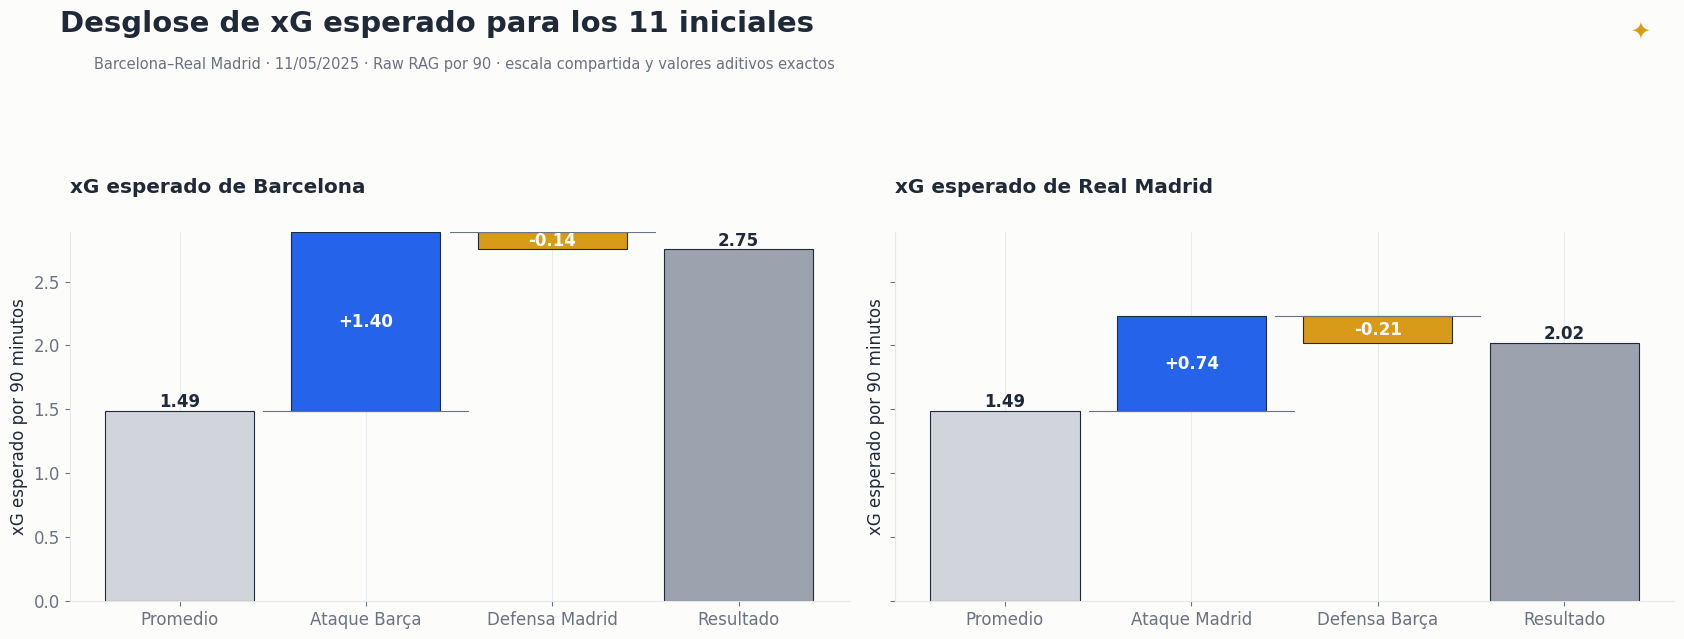

In [9]:
clasico = raw[raw["match_id"] == 28055].sort_values("segment_id")
assert len(clasico) == 19
assert clasico["minutes_played"].sum() == 98
assert np.isclose(clasico["teamA_xg"].sum(), 4.27)
assert np.isclose(clasico["teamB_xg"].sum(), 2.74)

first_segment = clasico.iloc[0]
barcelona_xi = first_segment["teamA_players"]
madrid_xi = first_segment["teamB_players"]
rating_lookup = ratings.set_index("player")
baseline = real_fit["baseline_90"]

barcelona_attack = rating_lookup.loc[barcelona_xi, "off_90"].sum()
madrid_defense_against = -rating_lookup.loc[madrid_xi, "def_90"].sum()
barcelona_prediction = baseline + barcelona_attack + madrid_defense_against

madrid_attack = rating_lookup.loc[madrid_xi, "off_90"].sum()
barcelona_defense_against = -rating_lookup.loc[barcelona_xi, "def_90"].sum()
madrid_prediction = baseline + madrid_attack + barcelona_defense_against

assert np.isclose(baseline + barcelona_attack + madrid_defense_against, barcelona_prediction)
assert np.isclose(baseline + madrid_attack + barcelona_defense_against, madrid_prediction)

# Contrato visual: descomposición aditiva; dos waterfalls comparables; dos raíces y valores exactos.
fig, axes = plt.subplots(1, 2, figsize=(17, 6.5), sharey=True)
draw_waterfall(
    axes[0], baseline,
    [("Ataque Barça", barcelona_attack), ("Defensa Madrid", madrid_defense_against)],
    barcelona_prediction, "xG esperado de Barcelona"
)
draw_waterfall(
    axes[1], baseline,
    [("Ataque Madrid", madrid_attack), ("Defensa Barça", barcelona_defense_against)],
    madrid_prediction, "xG esperado de Real Madrid"
)
fig.suptitle("Desglose de xG esperado para los 11 iniciales", x=0.04, ha="left", fontsize=21, fontweight="bold")
finish_chart(fig, "Barcelona–Real Madrid · 11/05/2025 · Raw RAG por 90 · escala compartida y valores aditivos exactos", subtitle_y=0.89)
plt.tight_layout(rect=(0, 0, 1, 0.82))
plt.show()

In [10]:
def lineup_top_three(lineup, team):
    table = rating_lookup.loc[lineup, ["off_90", "def_90", "total_90"]].copy()
    table.index = [player.split("_")[0] for player in table.index]
    table.index.name = team
    return table.nlargest(3, "total_90").round(2)

display(Markdown("### Tres jugadores con mayor impacto combinado entre cada XI inicial"))
display(lineup_top_three(barcelona_xi, "Barcelona"))
display(lineup_top_three(madrid_xi, "Real Madrid"))

### Tres jugadores con mayor impacto combinado entre cada XI inicial

,off_90,def_90,total_90
Barcelona,,,
Eric García,0.24,0.10,0.34
Lamine Yamal,0.28,0.05,0.33
Frenkie de Jong,0.27,-0.03,0.25


,off_90,def_90,total_90
Real Madrid,,,
Kylian Mbappé,0.27,0.00,0.28
Federico Valverde,0.10,0.12,0.22
Dani Ceballos,0.09,0.08,0.17


## 7. Qué nos llevamos

- Raw RAG no cuenta goles individuales: aprende cuánto cambia el xG cuando cada jugador está en la cancha.
- Los partidos recientes pesan más, por lo que el rating refleja mejor la forma actual.
- **Ridge** reduce conclusiones extremas cuando la evidencia es limitada.
- La interpretación correcta es “impacto estimado”, no causalidad perfecta: sin rotaciones suficientes, algunos compañeros siguen siendo difíciles de separar.

El siguiente paso del modelo combina este Raw RAG con contexto adicional; aquí dejamos aislada y visible su primera capa.

## Checks de reproducibilidad

- Fuente del extracto: tablas `match_general`, `match_detailed` y `teams` de `data/vsp.sql`.
- Granularidad: una fila por segmento de alineación.
- Entrenamiento: paridad con `_train_raw_rag` en `scripts/core.py`.
- Semilla sintética: `42`.
- El notebook se ejecuta únicamente con `data/raw_rag_la_liga.csv`.